# Phase_1: Data Loading and Exploration

##### Uncomment this cell to install all the libraries from requirments file

In [3]:
# %pip install -r requirements.txt

### Import Initial Libraries (Other Libraries will be Impoted later when needed)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading and checking the dataset size, shape and other characteristics

In [5]:
df = pd.read_csv('hand_landmarks_data.csv')
print(f"Dataset size: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset size: 25675 rows and 64 columns


In [6]:
df.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25675 entries, 0 to 25674
Data columns (total 64 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      25675 non-null  float64
 1   y1      25675 non-null  float64
 2   z1      25675 non-null  float64
 3   x2      25675 non-null  float64
 4   y2      25675 non-null  float64
 5   z2      25675 non-null  float64
 6   x3      25675 non-null  float64
 7   y3      25675 non-null  float64
 8   z3      25675 non-null  float64
 9   x4      25675 non-null  float64
 10  y4      25675 non-null  float64
 11  z4      25675 non-null  float64
 12  x5      25675 non-null  float64
 13  y5      25675 non-null  float64
 14  z5      25675 non-null  float64
 15  x6      25675 non-null  float64
 16  y6      25675 non-null  float64
 17  z6      25675 non-null  float64
 18  x7      25675 non-null  float64
 19  y7      25675 non-null  float64
 20  z7      25675 non-null  float64
 21  x8      25675 non-null  float64
 22

In [8]:
check_cols_nulls = df.isnull().sum()
totalnulls = check_cols_nulls.sum()
print(f"Total null values in the dataset: {totalnulls}")

Total null values in the dataset: 0


- *Note that This dataset is perfectly clean and has no missing values.*

Number of samples per gesture is label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64


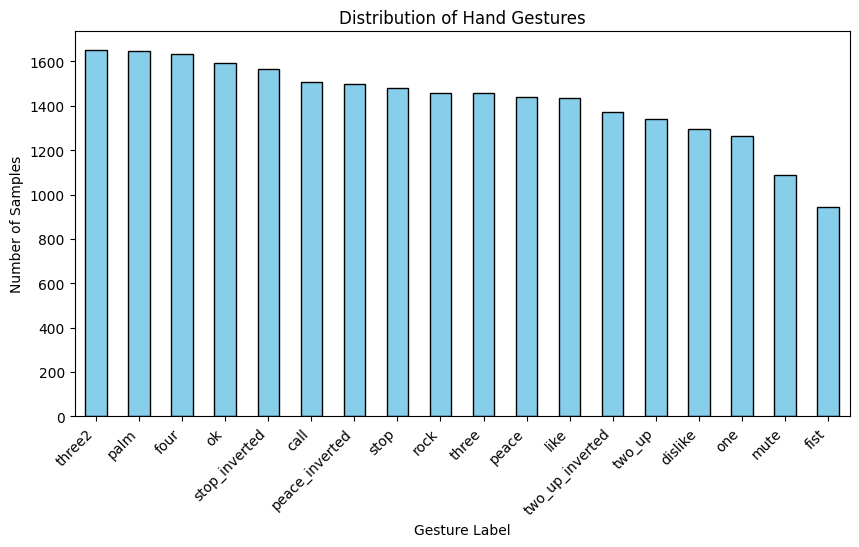

In [9]:
# Check whether the dataset is balanced or not by count how many samples we have for each gesture
gesture_counts = df['label'].value_counts()
print(f"Number of samples per gesture is {gesture_counts}")

plt.figure(figsize=(10, 5))
gesture_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Hand Gestures')
plt.xlabel('Gesture Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.show()

- *The dataset is well balanced as the difference betwwen most frequent and least is not huge*

# Phase_2: Data Preprocessing

### Normalization: If a person stands close to the camera, their hand looks huge. If they stand far away, their hand looks tiny. Also, the hand could be on the left or right side of the screen. We need the machine learning model to focus purely on the shape of the gesture, not where the hand is or how big it is. That's why We Normalized the data


In [10]:
# Create a copy of the dataset so we don't lose our original.
df_normalized = df.copy()

# In our CSV, x1 and y1 is the wrist. 
# x13 and y13 is the middle finger tip.
# We will loop through every row to apply the math
for index, row in df_normalized.iterrows():
    wrist_x = row['x1']
    wrist_y = row['y1']
    
    # Recenter all X and Y coordinates
    for i in range(1, 22):
        df_normalized.at[index, f'x{i}'] = row[f'x{i}'] - wrist_x
        df_normalized.at[index, f'y{i}'] = row[f'y{i}'] - wrist_y
        
    # Get the middle finger tip coordinates after recentering
    mid_tip_x = df_normalized.at[index, 'x13']
    mid_tip_y = df_normalized.at[index, 'y13']
    
    # Calculate the exact distance from the wrist to the mid-finger tip using the Pythagorean theorem
    distance = np.sqrt(mid_tip_x**2 + mid_tip_y**2)
    
    # Divide all X and Y coordinates by this distance to scale the hand
    # This number (1e-6) is to avoid dividing by exactly zero
    for i in range(1, 22):
        df_normalized.at[index, f'x{i}'] = df_normalized.at[index, f'x{i}'] / (distance + 1e-6)
        df_normalized.at[index, f'y{i}'] = df_normalized.at[index, f'y{i}'] / (distance + 1e-6)

print("Done Normalization")

Done Normalization


### - This function is to plot the Gestures before and after Normalization; call the function with the two parameters (name and sample_number) of the target gesture, you will notice the x and y axes numbers are always centerd on the right plot(normalized). 

In [11]:
def plot_before_after(gesture_name : str, sample_number = 0):
    # Find all rows matching the gesture name then pick the row index of the specific sample we want to plot.
    gesture_data = df[df['label'] == gesture_name]
    row_idx = gesture_data.index[sample_number]
    
    row_before = df.loc[row_idx]
    row_after = df_normalized.loc[row_idx]
    
    # These connections must be done manually since the dataset doesn't have a specific format for connections.
    # The connections are based on the MediaPipe hand landmark model, which has 21 keypoints
    # and defined to connect the wrist to the base of each finger, then connect each finger's keypoints in order.
    connections = [(1,2), (2,3), (3,4), (4,5), 
                   (1,6), (6,7), (7,8), (8,9),
                   (6,10), (10,11), (11,12), (12,13),
                   (10,14), (14,15), (15,16), (16,17),
                   (14,18), (18,19), (19,20), (20,21),
                   (1,18)]
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Before Normalization 
    axes[0].set_title(f'"{gesture_name}" Before Math')
    axes[0].invert_yaxis()
    x_before = [row_before[f'x{i}'] for i in range(1, 22)]
    y_before = [row_before[f'y{i}'] for i in range(1, 22)]
    
    for start, end in connections:
        axes[0].plot([x_before[start-1], x_before[end-1]], 
                     [y_before[start-1], y_before[end-1]], color='blue')
        
# After Normalization 
    axes[1].set_title(f'"{gesture_name}" After Math (Wrist at 0,0)')
    axes[1].invert_yaxis()
    x_after = [row_after[f'x{i}'] for i in range(1, 22)]
    y_after = [row_after[f'y{i}'] for i in range(1, 22)]
    
    for start, end in connections:
        axes[1].plot([x_after[start-1], x_after[end-1]], 
                     [y_after[start-1], y_after[end-1]], color='red')

    plt.grid(True)      
    plt.show()

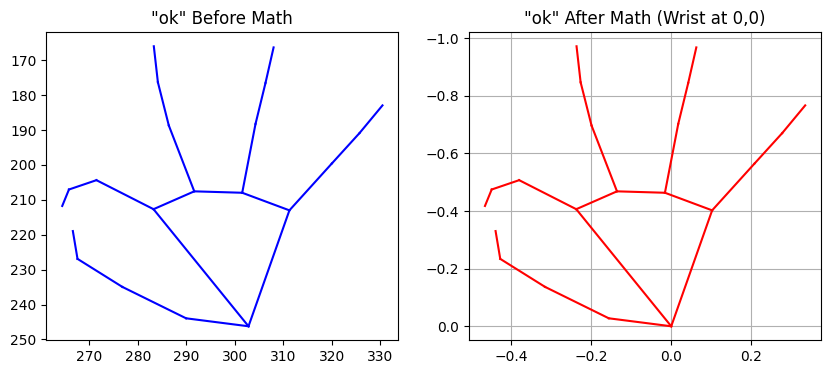

In [12]:
plot_before_after("ok", sample_number = 6)

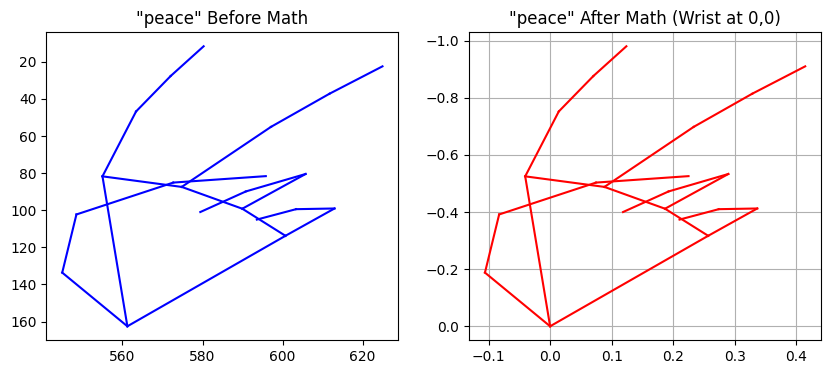

In [13]:
plot_before_after("peace", sample_number = 0)

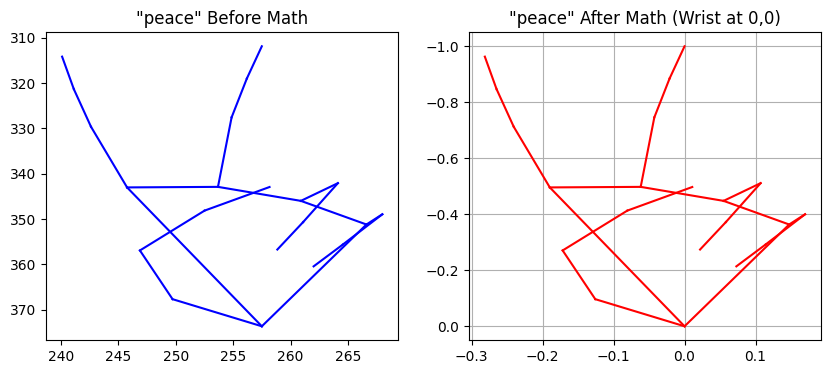

In [14]:
plot_before_after("peace", sample_number = 6)

# Phase_3: Model Preparation

In [15]:
from sklearn.model_selection import train_test_split

# split the datset into features and labels
X = df_normalized.drop('label', axis=1)
y = df_normalized['label']

# First split: 70% for Training, 30% for Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Second split: Divide the 30% Temporary data equally (50% of 30% = 15% each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Training features (X_train): {X_train.shape[0]} rows (70%)")
print(f"Validation features (X_val): {X_val.shape[0]} rows (15%)")
print(f"Testing features (X_test): {X_test.shape[0]} rows (15%)")

Training features (X_train): 17972 rows (70%)
Validation features (X_val): 3851 rows (15%)
Testing features (X_test): 3852 rows (15%)


# Phase_4: Model Trainig

## KNN
- ####  Starting by one of the simpliest and most common models, KNN. First check the optimum value of k acroos 20 different values and then choose it to train the model and see resulted metric we will get.


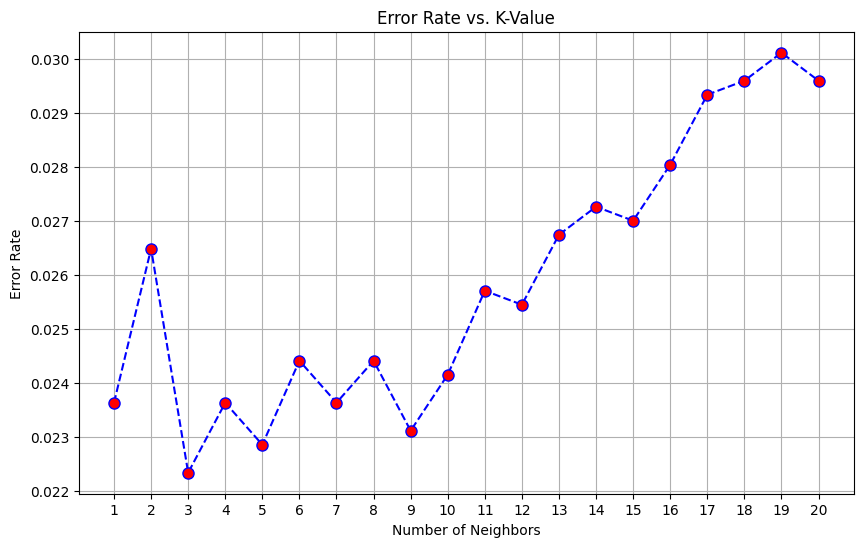

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

error_rates = []
k_values = range(1, 21) # k from 1 to 20

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_val = knn.predict(X_val)
    
    error = 1 - accuracy_score(y_val, y_pred_val)
    error_rates.append(error)

# Plot the calculated error rates to see which K value gives us the lowest error rate
plt.figure(figsize=(10, 6))
plt.plot(k_values, error_rates, color='blue', linestyle='dashed', 
         marker='o', markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K-Value')
plt.xlabel('Number of Neighbors')
plt.ylabel('Error Rate')
plt.xticks(k_values)
plt.grid(True)
plt.show()

- #### Notice here k = 3 has the lowest error value. However, using k = 5 or even k = 9 will get more stable model and the error difference is almost the same just a very slight cahnge between them. Uisng 3 is also fine. 
- #### Notice that even errors are worse than odd as they might get a tie votes.

In [17]:
# Import functions to calculate our scores
from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize empty dictionaries to store our final models and their scores
# These two dicts will store all the models we will train not only this one.
models_dict = {}
metrics_dict = {}

final_knn = KNeighborsClassifier(n_neighbors = 5)
final_knn.fit(X_train, y_train)

y_pred_knn = final_knn.predict(X_val)

acc = accuracy_score(y_val, y_pred_knn)
prec = precision_score(y_val, y_pred_knn, average='weighted', zero_division=0)
rec = recall_score(y_val, y_pred_knn, average='weighted', zero_division=0)
f1 = f1_score(y_val, y_pred_knn, average='weighted', zero_division=0)

print(f"Final KNN Accuracy: {acc:.4f}")

models_dict["KNN"] = final_knn
metrics_dict["KNN"] = {
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1
}

Final KNN Accuracy: 0.9771


## Logistic Regression
- ### Second check the Logistic Regression using the gridsearch to tune hyperparameters and apply cross validation with 5 folds.
- ### C: it is the inverse of regularization strength, smaller vlues prevent model from overfitting
- ### solver: is the optimization algorithm used to minimize the loss function

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define parameter grid for GridSearch
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000] # High iteration count to ensure convergence
}

lr_base = LogisticRegression(random_state=42)

grid_lr = GridSearchCV(estimator=lr_base, param_grid=param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

print("Excuting GridSearchCV for Logistic Regression: ")
start_time = time.time()
grid_lr.fit(X_train, y_train)
print(f"Execution Time = {(time.time() - start_time):.2f} seconds")

# Extract the optimal model
best_lr = grid_lr.best_estimator_
print(f"Optimal Parameters are: {grid_lr.best_params_}")

y_pred_lr = best_lr.predict(X_val)

acc_lr = accuracy_score(y_val, y_pred_lr)
prec_lr = precision_score(y_val, y_pred_lr, average='weighted', zero_division=0)
rec_lr = recall_score(y_val, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_val, y_pred_lr, average='weighted', zero_division=0)

print(f"Validation Accuracy: {acc_lr:.4f}")

# Append to registry dictionaries
models_dict["Logistic Regression"] = best_lr
metrics_dict["Logistic Regression"] = {
    "accuracy": acc_lr,
    "precision": prec_lr,
    "recall": rec_lr,
    "f1_score": f1_lr
}

Excuting GridSearchCV for Logistic Regression: 
Fitting 5 folds for each of 6 candidates, totalling 30 fits


Execution Time = 961.80 seconds
Optimal Parameters are: {'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}
Validation Accuracy: 0.8876


### 16 minutes is quite much, but that's because we were doint 30 training runs, and the datset aslo has 25k sample. the accuracy is not the best compared to the knn though.

## SVM
- #### Third, check the Support Vector Machine using GridSearchCV to tune hyperparameters.
- #### Use SVC for categorical Data
- #### C: Controls the penalty for mistakes. A smaller C makes a smoother decision boundary, while a larger C tries to classify every single point correctly.
- #### kernel: The mathematical function used to draw the boundary ('linear' for straight lines, 'rbf' for complex curves).

In [19]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid_svm = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf'] }

svm_base = SVC(random_state=42)

# CV = 3; 3-fold cross-validation to save time. 
grid_svm = GridSearchCV(estimator=svm_base, param_grid=param_grid_svm, cv = 5, scoring='accuracy', n_jobs=-1, verbose=2)

print("Executing GridSearchCV for SVM: ")
start_time = time.time()

grid_svm.fit(X_train, y_train)

execution_time = (time.time() - start_time) / 60
print(f"Execution Time: {execution_time:.2f} minutes.")

best_svm = grid_svm.best_estimator_
print(f"Optimal Parameters: {grid_svm.best_params_}")

y_pred_svm = best_svm.predict(X_val)

acc_svm = accuracy_score(y_val, y_pred_svm)
prec_svm = precision_score(y_val, y_pred_svm, average='weighted', zero_division=0)
rec_svm = recall_score(y_val, y_pred_svm, average='weighted', zero_division=0)
f1_svm = f1_score(y_val, y_pred_svm, average='weighted', zero_division=0)

print(f"Validation Accuracy: {acc_svm:.4f}")

models_dict["SVM"] = best_svm
metrics_dict["SVM"] = {
    "accuracy": acc_svm,
    "precision": prec_svm,
    "recall": rec_svm,
    "f1_score": f1_svm
}

Executing GridSearchCV for SVM: 
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Execution Time: 1.07 minutes.
Optimal Parameters: {'C': 10, 'kernel': 'rbf'}
Validation Accuracy: 0.9782


## Random Forest
- #### Fourth, check the Random Forest using GridSearchCV to tune hyperparameters.
- #### n_estimators: Number of decision trees.
- #### max_depth: How deep each tree can grow.
- #### min_samples_split & min_samples_leaf: Controls the size of the leaves and splits to prevent overfitting.(left as default)
- #### max_features: The subset of features considered for each split, adding diversity to the forest.(left as default)

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

param_grid_rf = {
    'n_estimators': [250, 300],
    'max_depth': [25, 30],
}

rf_base = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

print("Executing GridSearchCV for Random Forest: ")
start_time = time.time()

grid_rf.fit(X_train, y_train)

execution_time = (time.time() - start_time) / 60
print(f"Execution Time: {execution_time:.2f} minutes.")

best_rf = grid_rf.best_estimator_
print(f"Optimal Parameters: {grid_rf.best_params_}")

y_pred_rf = best_rf.predict(X_val)

acc_rf = accuracy_score(y_val, y_pred_rf)
prec_rf = precision_score(y_val, y_pred_rf, average='weighted', zero_division=0)
rec_rf = recall_score(y_val, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_val, y_pred_rf, average='weighted', zero_division=0)

print(f"Validation Accuracy: {acc_rf:.4f}")

models_dict["Random Forest"] = best_rf
metrics_dict["Random Forest"] = {
    "accuracy": acc_rf,
    "precision": prec_rf,
    "recall": rec_rf,
    "f1_score": f1_rf
}

Executing GridSearchCV for Random Forest: 
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Execution Time: 10.98 minutes.
Optimal Parameters: {'max_depth': 25, 'n_estimators': 300}
Validation Accuracy: 0.9771


# Phase_5: Comparing and Evaluating Models


----------------> Final Model Comparison <----------------


,accuracy,precision,recall,f1_score
SVM,0.978187,0.978737,0.978187,0.978202
KNN,0.977149,0.977495,0.977149,0.977216
Random Forest,0.977149,0.977497,0.977149,0.977209
Logistic Regression,0.887562,0.888110,0.887562,0.887341


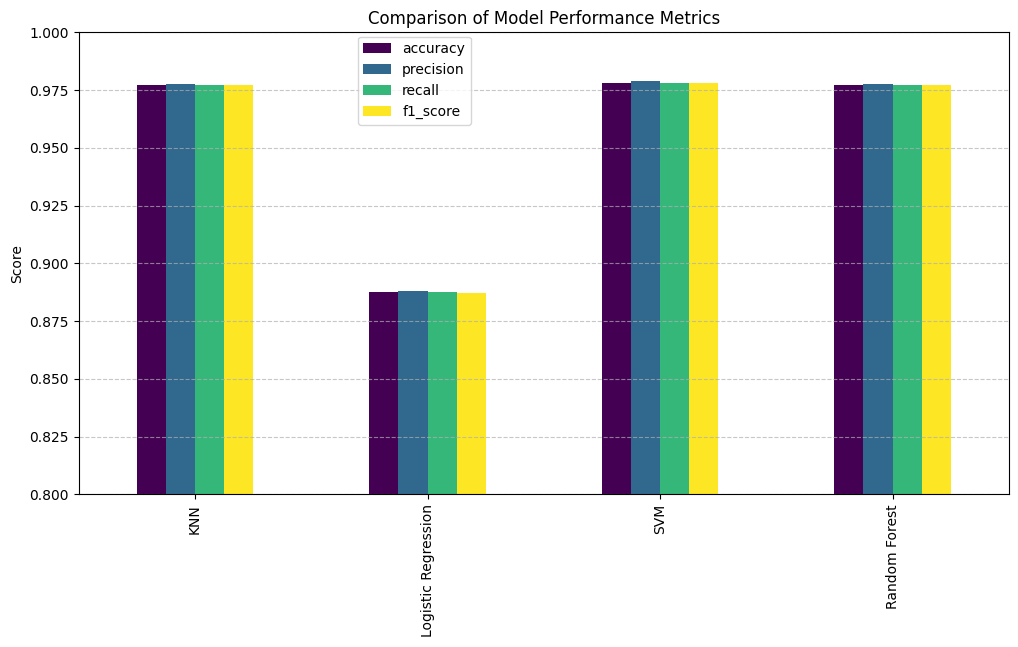

In [21]:
# Convert the metrics dictionary into a Pandas DataFrame for easy visualization
# .T transposes the table so the model names become the rows
metrics_df = pd.DataFrame(metrics_dict).T

print("----------------> Final Model Comparison <----------------")
# Sort by accuracy so the best model is at the top
display(metrics_df.sort_values(by='accuracy', ascending=False))

# Plot a grouped bar chart for all metrics
metrics_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')

plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0.8, 1.0) # as scores are very close limit the axis to 0.8 - 1 for better visibility of differences
plt.legend(loc=(0.3,0.8)) # best place for the legend as shown
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Conclusion & Model Selection
- #### As shown in the comparison metrics, SVM, KNN, and Random Forest perform almost identically at ~97.7% - 97.8% accuracy. Logistic Regression lagged significantly behind at ~88.7%.
- #### Limiting the Y-axis to the 0.85 - 1.0 range provides a clearer visual distinction between the models.
- #### SVM achieved the highest overall metrics by a slight margin. Therefore, SVM is selected as the primary model to be deployed and tested for the final live video implementation.

# Phase_6: ML Flow

In [26]:
from mlflow_utils import setup_mlflow, log_models
import mlflow

# Initialize the local mlruns folder and experiment
setup_mlflow("Hand_Gesture_Recognition")

print("Executing MLflow logging for all models")
# Call & execute our custom utility function
run_ids = log_models(models_dict, metrics_dict, X_val, y_val)

# Put the winning model into the Model Registry
# We extract the specific Run ID for the SVM that we just saved
svm_run_id = run_ids["SVM"]
model_uri = f"runs:/{svm_run_id}/model"

print("Registering the winning SVM model to the MLflow Model Registry")

mlflow.register_model(model_uri=model_uri, name="Primary_Gesture_Classifier_SVM")

Executing MLflow logging for all models
Registering the winning SVM model to the MLflow Model Registry


Registered model 'Primary_Gesture_Classifier_SVM' already exists. Creating a new version of this model...
Created version '2' of model 'Primary_Gesture_Classifier_SVM'.


<ModelVersion: aliases=[], creation_timestamp=1773306078804, current_stage='None', description=None, last_updated_timestamp=1773306078804, name='Primary_Gesture_Classifier_SVM', run_id='63f118fea9064404936e06bdf16e83c6', run_link=None, source=('file:///e:/Machine Learning 1/Hand Gesture '
 'Project/mlruns/162904957146518738/63f118fea9064404936e06bdf16e83c6/artifacts/model'), status='READY', status_message=None, tags={}, user_id=None, version=2>

# Phase_7: Final evaluation and Video

#### Final Model Evaluation on Unseen Test Data
- After selecting SVM as our primary model based on validation metrics, we must administer a final evaluation using the locked-out test set (X_test). This step ensures no data leakage occurred during hyperparameter tuning and provides a mathematically unbiased estimate of real-world performance for the live video feed.

In [24]:
final_svm = models_dict["SVM"]

y_pred_test = final_svm.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")

Test Accuracy:  0.9748
Test Precision: 0.9753
Test Recall:    0.9748
Test F1-Score:  0.9749


- ##### Final Evaluation Analysis
The SVM model achieved 97.48% accuracy on the isolated test dataset. The negligible drop from the validation phase (0.34%) confirms the absence of overfitting.
The high symmetry between precision and recall indicates robust, unbiased classification across all hand gestures, validating its readiness for real-time video inference.

#### Real-Time OpenCV Video Inference
- this step is done in a separated .py file called live_inderence for the following reasons.
- It is possible and normal to do it in the notebook though.


1. **Kernel Stability:** OpenCV's `cv2.imshow` function creates a separate GUI thread. Running this inside the Jupyter event loop frequently causes the kernel to hang or crash due to resource contention.

2. **Hardware Access:** Standalone execution provides more stable and direct access to the webcam hardware, resulting in a higher and more consistent Frame Rate (FPS).

In [25]:
import pickle

# Save the winning SVM model directly to the project folder
with open("deploy_svm.pkl", "wb") as f:
    pickle.dump(models_dict["SVM"], f)
print("Model saved to disk successfully.")

Model saved to disk successfully.


- ##### Unccoment this line of code to run the standalone live inference script
- ##### Ensure your webcam is connected and not being used by another app


In [ ]:
#!python live_inference.py